# Exploración de Datos — Llegadas de Vehículos, Terminal de Transporte

**Curso:** Modelos y Simulación de Sistemas I — Proyecto integrador, Fase 1
**Dataset:** [Llegadas y Salidas de Vehículos de la Terminal de Transporte](https://www.datos.gov.co/Transporte/Llegada-y-Salidas-de-Veh-culos-de-la-Terminal-de-T/pfsr-mdyi/about_data) — Datos Abiertos Colombia (recurso `pfsr-mdyi`)
**Problema:** predecir la **duración de un viaje** (`duracion_viaje_horas`, en horas) a partir de información disponible al momento de la salida — regresión de tipo ETA (tiempo estimado de llegada).

## Datos utilizados

Se trabaja con el **conjunto de datos completo** publicado en el portal (todas las clases de vehículo y todos los registros hasta el 31-12-2025), descargado íntegramente desde la API. No se usa una muestra: cualquier submuestreo del recurso, dado el orden cronológico en que la API entrega los registros, tiende a concentrarse en unos pocos meses y sesga el análisis (estacionalidad, cambios en la captura de los datos, etc.).

## Orden de este notebook

La exploración se hace sobre el dato **crudo** (tal como llega, sin descartar ni transformar columnas) antes de derivar la variable objetivo, para que cualquier decisión de limpieza quede respaldada por evidencia y no por suposición:

- **Fase A — Exploración cruda** (Pasos 1 a 5): dimensiones, nulos, tipos de datos, variables categóricas y patrones de valores faltantes, sobre las 12 columnas originales, sin excepción, incluidas las que a primera vista parecen no aportar (como `estado`).
- **Fase B — Variables numéricas** (Pasos 6 a 9): se derivan las variables numéricas que no vienen dadas (`duracion_viaje_horas` —el objetivo—, `hora_salida_decimal`, `dia_semana` y `mes`), cada una justificada, y se analizan sus estadísticas, correlaciones y relación con el objetivo.

Las decisiones de limpieza (qué columnas se eliminan, cómo se tratan los nulos y los valores inválidos) **no se toman en este notebook**: se toman en el de preparación de datos, con la evidencia recogida aquí como respaldo.


## Configuración e imports

In [1]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

SEED = 42
BASE_URL = "https://www.datos.gov.co/resource/pfsr-mdyi.json"

# Las 12 columnas originales del recurso (verificadas contra los metadatos del dataset).
COLUMNS = [
    "estado", "nombre_sucursal", "empresa", "fecha_salida",
    "fecha_hora_salida_origen", "fecha_llegada", "hora_de_llegada",
    "ruta_origen", "ruta_destino", "subregi_n", "clase_veh_culo", "pasajeros",
]

RAW_PATH = "../data/raw/datos_completos.csv"
PAGE_SIZE = 50_000
# Corte fijo: el recurso solo contiene datos hasta 2025; fijar el corte hace que la descarga sea
# reproducible aunque el portal agregue registros nuevos en el futuro.
WHERE = "`hora_de_llegada` < '2026-01-01T00:00:00'"


# FASE A — Exploración cruda (sin modificar ni descartar nada)

Todo lo que sigue trabaja sobre las 12 columnas originales, exactamente como las entrega la API. No se deriva ni se elimina ninguna columna en esta fase (solo se reconoce el tipo de cada una para poder inspeccionarla).


## Paso 1 — Cargar los datos e inspeccionar dimensiones

**Qué se hace:** descargar el recurso completo (todas las clases de vehículo) y revisar dimensiones, columnas y primeras filas.

**Cómo se descarga:** la API devuelve como máximo unas decenas de miles de filas por consulta, así que se pagina (`LIMIT`/`OFFSET`) con un orden estable (`ORDER BY :id`, el identificador interno de cada fila) para que ninguna página se repita ni se omita. Cada página se escribe a disco a medida que llega (así no se acumulan millones de filas en memoria) y, al terminar, se verifica que el número de filas descargadas coincida con el conteo que reporta el servidor. El archivo queda en caché local: si ya existe, no se vuelve a descargar.


In [2]:
def server_count():
    r = requests.get(BASE_URL, params={"$query": f"SELECT count(*) as n WHERE {WHERE}"}, timeout=120)
    r.raise_for_status()
    return int(r.json()[0]["n"])


def download_full(path, page_size=PAGE_SIZE, max_retries=3):
    select_cols = ", ".join(f"`{c}`" for c in COLUMNS)
    total = server_count()
    tmp = path + ".part"
    written, offset, first = 0, 0, True
    while offset < total:
        query = f"SELECT {select_cols} WHERE {WHERE} ORDER BY :id LIMIT {page_size} OFFSET {offset}"
        for attempt in range(max_retries):
            try:
                r = requests.get(BASE_URL, params={"$query": query}, timeout=300)
                r.raise_for_status()
                rows = r.json()
                break
            except Exception:
                if attempt == max_retries - 1:
                    raise
                time.sleep(5 * (attempt + 1))
        if not rows:
            break
        # La API omite las claves de los campos nulos: reindex las restituye como vacios.
        page = pd.DataFrame(rows).reindex(columns=COLUMNS)
        page.to_csv(tmp, mode="w" if first else "a", header=first, index=False)
        first = False
        written += len(page)
        offset += page_size
        print(f"{written:>10,} / {total:,}")
    os.replace(tmp, path)
    return written, total


In [3]:
os.makedirs(os.path.dirname(RAW_PATH), exist_ok=True)
if os.path.exists(RAW_PATH):
    print("Archivo local encontrado, no se vuelve a descargar:", RAW_PATH)
else:
    written, total = download_full(RAW_PATH)
    assert written == total, f"Descarga incompleta: {written:,} de {total:,}"
    print("Descarga completa y verificada.")


Archivo local encontrado, no se vuelve a descargar: ../data/raw/datos_completos.csv


In [4]:
df_raw = pd.read_csv(RAW_PATH, dtype=str)   # todo como texto: exactamente como llega
print("Dimensiones (filas, columnas):", df_raw.shape)
print("Filas segun el servidor:      ", f"{server_count():,}")
print("\nColumnas:", list(df_raw.columns))
print("Filas exactamente duplicadas:", f"{df_raw.duplicated().sum():,}")
df_raw.head()


Dimensiones (filas, columnas): (2617130, 12)


Filas segun el servidor:       2,617,130

Columnas: ['estado', 'nombre_sucursal', 'empresa', 'fecha_salida', 'fecha_hora_salida_origen', 'fecha_llegada', 'hora_de_llegada', 'ruta_origen', 'ruta_destino', 'subregi_n', 'clase_veh_culo', 'pasajeros']


Filas exactamente duplicadas: 3,790


,estado,nombre_sucursal,empresa,fecha_salida,fecha_hora_salida_origen,fecha_llegada,hora_de_llegada,ruta_origen,ruta_destino,subregi_n,clase_veh_culo,pasajeros
0,LLEGADA,TERMINAL DEL NORTE,COONORTE,2023-12-31T18:00:00.000,2023-12-31T18:00:00.000,2024-01-01T00:27:00.000,2024-01-01T00:27:00.000,CAUCASIA,MEDELLIN,NORTE,BUS,8
1,LLEGADA,TERMINAL DEL NORTE,TRANS GOMEZ HERNANDEZ,2023-12-31T18:30:00.000,2023-12-31T18:30:00.000,2024-01-01T02:26:00.000,2024-01-01T02:26:00.000,TURBO,MEDELLIN,NORTE,BUS,15
2,LLEGADA,TERMINAL DEL NORTE,RAPIDO OCHOA,2023-12-31T18:30:00.000,2023-12-31T18:30:00.000,2024-01-01T03:57:00.000,2024-01-01T03:57:00.000,BOGOTA,MEDELLIN,NORTE,BUS,40
3,LLEGADA,TERMINAL DEL NORTE,COONORTE,2023-12-31T19:45:00.000,2023-12-31T19:45:00.000,2024-01-01T04:23:00.000,2024-01-01T04:23:00.000,BOGOTA,MEDELLIN,NORTE,BUS,35
4,LLEGADA,TERMINAL DEL NORTE,COONORTE,2023-12-31T20:00:00.000,2023-12-31T20:00:00.000,2024-01-01T04:37:00.000,2024-01-01T04:37:00.000,AYAPEL,MEDELLIN,NORTE,BUS,10


### Descripción del conjunto de datos y limitaciones

- **Observaciones:** 2.617.130 filas. Cada fila es la llegada de un vehículo a una de las dos terminales de Medellín, entre febrero de 2023 y diciembre de 2025.
- **Variables:** 12 columnas originales: 7 categóricas (`estado`, `nombre_sucursal`, `empresa`, `ruta_origen`, `ruta_destino`, `subregi_n`, `clase_veh_culo`), 4 de fecha/hora (`fecha_salida`, `fecha_hora_salida_origen`, `fecha_llegada`, `hora_de_llegada`) y 1 numérica (`pasajeros`).
- **Variable objetivo:** `duracion_viaje_horas`, el tiempo entre la salida real del vehículo desde su origen y su llegada real a la terminal, en horas. No viene como columna: se deriva en el Paso 6.
- **Limitaciones del conjunto de datos** (la evidencia de cada una está en el paso indicado):
  1. **Solo llegadas a Medellín.** `estado` y `ruta_destino` no varían (Paso 4): el modelo solo puede estimar la duración de viajes que terminan en Medellín.
  2. **Dos convenciones de captura.** En 2023 y 2025, `fecha_salida` y `fecha_llegada` traen solo la fecha (la hora vive en `fecha_hora_salida_origen` y `hora_de_llegada`); en 2024 traen la hora completa y `fecha_hora_salida_origen` casi no se diligencia (Pasos 5 y 6). La duración exige reconstruir la hora de salida combinando ambas fuentes.
  3. **Cobertura temporal.** Enero de 2023 está casi vacío (2.112 filas frente a 63.000-83.000 de los demás meses), así que los datos útiles empiezan en febrero de 2023 (Paso 6).
  4. **Errores de captura en las fechas.** Hay duraciones negativas, duraciones de cientos o miles de horas y unas decenas de filas con año de salida imposible (2002-2012, 2029) o sin fecha de salida (Pasos 6 y 7).
  5. **Sin identificador de viaje ni de vehículo.** No se puede confirmar si las 3.790 filas idénticas (0.14%) son errores ni analizar dependencias entre viajes de un mismo vehículo.
  6. **`pasajeros`** es el conteo registrado en la llegada (podría incluir pasajeros que abordaron en ruta) y tiene algún valor imposible (máximo de 259 en un BUS) (Paso 7).
  7. **Faltan variables que explican las demoras** (distancia de la ruta, clima, tráfico, festivos): el modelo solo puede aprender lo que la ruta, la empresa, el vehículo y el horario permiten inferir.


## Paso 2 — Conteo rápido de valores faltantes por columna

Chequeo rápido de calidad de datos sobre las 12 columnas originales.


In [5]:
nulls = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "pct_nulos": (df_raw.isna().mean() * 100).round(4),
}).sort_values("pct_nulos", ascending=False)
nulls


,nulos,pct_nulos
fecha_hora_salida_origen,875015,33.4341
empresa,29,0.0011
clase_veh_culo,7,0.0003
fecha_salida,5,0.0002
estado,0,0.0000
nombre_sucursal,0,0.0000
hora_de_llegada,0,0.0000
fecha_llegada,0,0.0000
ruta_origen,0,0.0000
ruta_destino,0,0.0000


**Lectura:** solo `fecha_hora_salida_origen` tiene una proporción relevante de nulos (875.015 filas, **33.43%**). `empresa` (29 filas), `clase_veh_culo` (7) y `fecha_salida` (5) tienen apenas unas decenas de filas faltantes (menos de 0.002%) y el resto de columnas están completas. Que un tercio de una columna falte obliga a entender *por qué* (Paso 5) antes de decidir cómo tratarlo.


## Paso 3 — Descubrir los tipos de datos (*Discover data types*)

Se revisa qué tipo trae realmente cada columna y se reconoce su tipo real (fechas como fecha, `pasajeros` como número, textos repetitivos como categorías). Esto es **reconocer** el tipo del dato, no derivar información nueva. Se cuantifica también cuántos valores no logran interpretarse, para no perderlos en silencio.


In [6]:
print("Tipos ANTES de reconocer fechas y numeros:")
df_raw.dtypes


Tipos ANTES de reconocer fechas y numeros:


estado                      str
nombre_sucursal             str
empresa                     str
fecha_salida                str
fecha_hora_salida_origen    str
fecha_llegada               str
hora_de_llegada             str
ruta_origen                 str
ruta_destino                str
subregi_n                   str
clase_veh_culo              str
pasajeros                   str
dtype: object

In [7]:
DATE_FMT = "%Y-%m-%dT%H:%M:%S.%f"
date_cols = ["fecha_salida", "fecha_hora_salida_origen", "fecha_llegada", "hora_de_llegada"]
categorical_cols = ["estado", "nombre_sucursal", "empresa", "ruta_origen",
                    "ruta_destino", "subregi_n", "clase_veh_culo"]

df = df_raw
for c in date_cols:
    parsed = pd.to_datetime(df[c], format=DATE_FMT, errors="coerce")
    print(f"{c:<28} valores no interpretables como fecha: {int((df[c].notna() & parsed.isna()).sum())}")
    df[c] = parsed

pas = pd.to_numeric(df["pasajeros"], errors="coerce")
print(f"{'pasajeros':<28} valores no interpretables como numero: {int((df['pasajeros'].notna() & pas.isna()).sum())}")
df["pasajeros"] = pas

for c in categorical_cols:
    df[c] = df[c].astype("category")

print("\nTipos DESPUES de reconocer fechas y numeros:")
df.dtypes


fecha_salida                 valores no interpretables como fecha: 0


fecha_hora_salida_origen     valores no interpretables como fecha: 0


fecha_llegada                valores no interpretables como fecha: 0


hora_de_llegada              valores no interpretables como fecha: 0


pasajeros                    valores no interpretables como numero: 0



Tipos DESPUES de reconocer fechas y numeros:


estado                            category
nombre_sucursal                   category
empresa                           category
fecha_salida                datetime64[us]
fecha_hora_salida_origen    datetime64[us]
fecha_llegada               datetime64[us]
hora_de_llegada             datetime64[us]
ruta_origen                       category
ruta_destino                      category
subregi_n                         category
clase_veh_culo                    category
pasajeros                            int64
dtype: object

De las 12 columnas originales, **solo `pasajeros` es numérica**: las cuatro columnas de fecha son fecha/hora y el resto son categóricas. Por eso las estadísticas numéricas y las correlaciones se hacen en la Fase B, cuando ya existan las variables numéricas derivadas.


## Paso 4 — Inspeccionar variables categóricas (*Inspect categorical variables*)

Se analizan **todas** las categóricas originales, incluida `estado`, aunque de una exploración previa se sospechaba que es constante. La idea es demostrarlo aquí con evidencia (no descartarla "porque ya se sabía"), para poder documentar esa evidencia como justificación cuando se decida eliminarla.


In [8]:
for c in categorical_cols:
    print(f"\n=== {c} (cardinalidad: {df[c].nunique()}) ===")
    print(df[c].value_counts(dropna=False).head(10))



=== estado (cardinalidad: 2) ===
estado
LLEGADA    1812830
Llegada     804300
Name: count, dtype: int64

=== nombre_sucursal (cardinalidad: 4) ===
nombre_sucursal
Terminal del Norte    1259339
TERMINAL DEL NORTE     652675
Terminal del Sur       459884
TERMINAL DEL SUR       245232
Name: count, dtype: int64

=== empresa (cardinalidad: 169) ===
empresa
COOPETRANSA                                   189671
COONORTE                                      169042
RAPIDO MEDELLIN RIONEGRO S.A.                 143758
SOTRAURABA                                    120775
TRANSUNIDOS                                   110452
TRANS GOMEZ HERNANDEZ                         109999
EXPRE - BELMIRA S.A.                          104807
TRANSORIENTE                                   87950
SOTRAMAR                                       85060
SOTRASANVICENTE & GUATAPE LA PIEDRA S.C.A.     74210
Name: count, dtype: int64



=== ruta_origen (cardinalidad: 412) ===
ruta_origen
RIONEGRO                              214746
RIONEGRO-MEDELLIN                     113697
SAN PEDRO DE LOS MILAGROS             100162
MARINILLA                              61819
SANTA FE DE ANTIOQUIA                  60783
LA CEJA                                58486
SAN PEDRO DE LOS MILAGROS-MEDELLIN     52811
GUARNE                                 46388
EL SANTUARIO                           42947
EL CARMEN DE VIBORAL                   41980
Name: count, dtype: int64



=== ruta_destino (cardinalidad: 1) ===
ruta_destino
MEDELLIN    2617130
Name: count, dtype: int64

=== subregi_n (cardinalidad: 10) ===
subregi_n
Oriente      674842
Norte        509058
ORIENTE      350339
Sur          268291
NORTE        264829
Occidente    154587
SUR          143611
Centro       112445
OCCIDENTE     79845
CENTRO        59283
Name: count, dtype: int64

=== clase_veh_culo (cardinalidad: 6) ===
clase_veh_culo
BUS          1323369
MICROBUS      716448
CAMIONETA     525980
AUTOMOVIL      40192
DUO BUS        11130
NaN                7
bus                4
Name: count, dtype: int64


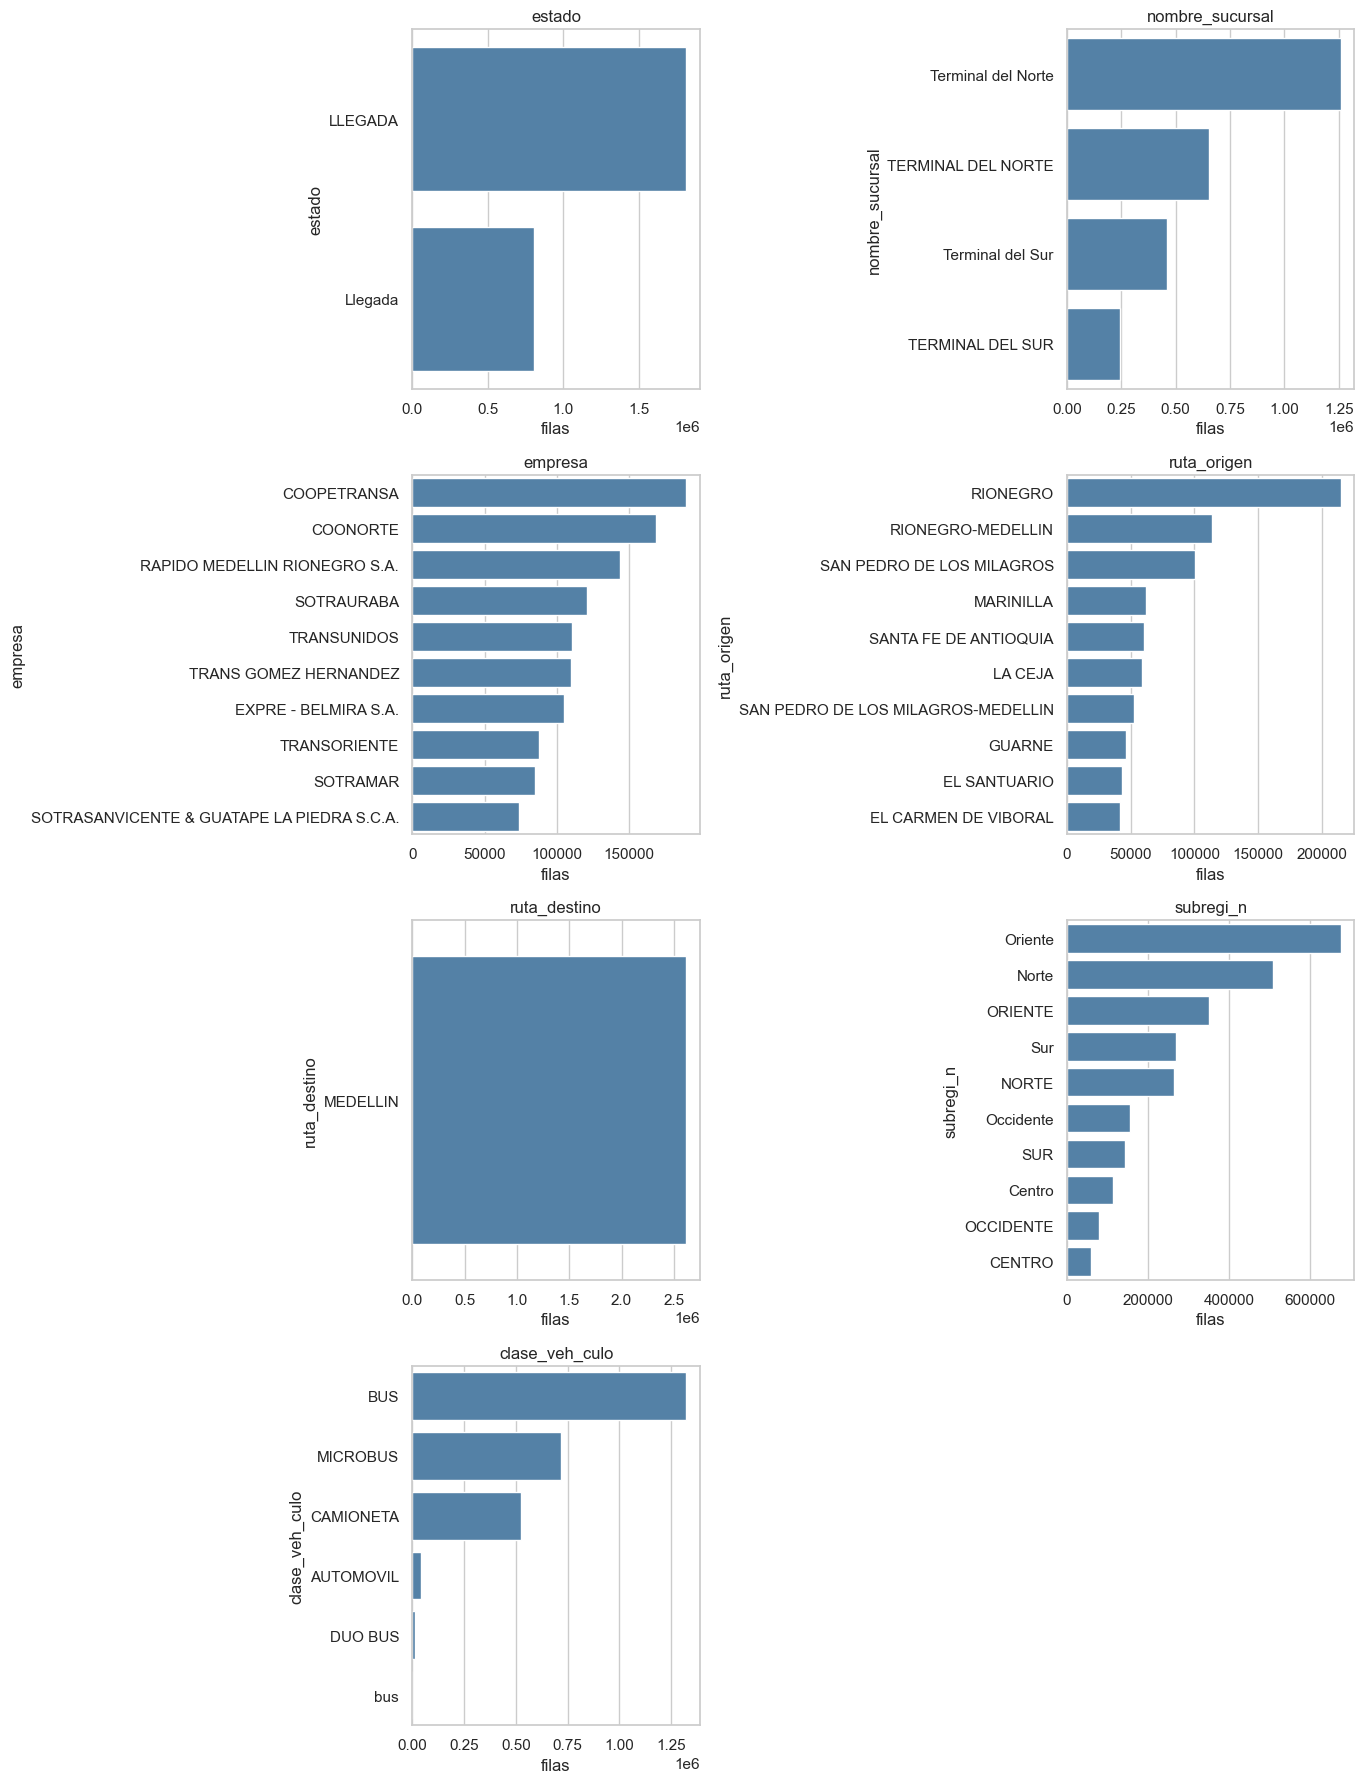

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for ax, c in zip(axes, categorical_cols):
    top = df[c].value_counts(dropna=False).head(10)
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color="steelblue")
    ax.set_title(c)
    ax.set_xlabel("filas")
for ax in axes[len(categorical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


**Hallazgos:**
- `estado`: solo dos valores, "LLEGADA" (1.812.830) y "Llegada" (804.300): es el mismo valor con una diferencia de mayúsculas. **Varianza cero**: no puede aportar nada como predictora.
- `ruta_destino`: "MEDELLIN" en el 100% de las filas. **Varianza cero**, consecuencia de que el recurso contiene solo llegadas a Medellín.
- `nombre_sucursal`: 4 valores que en realidad son **2 terminales** (Norte: 1.912.014 filas; Sur: 705.116), cada una escrita de dos maneras ("Terminal del Norte" / "TERMINAL DEL NORTE"). Las dos escrituras corresponden a las dos convenciones de captura que se verán en el Paso 6.
- `subregi_n`: 10 valores que son **5 subregiones** (Oriente, Norte, Sur, Occidente, Centro) duplicadas por mayúsculas.
- `clase_veh_culo`: 5 clases (BUS 1.323.369; MICROBUS 716.448; CAMIONETA 525.980; AUTOMOVIL 40.192; DUO BUS 11.130), más 4 filas escritas "bus" en minúscula y 7 sin valor.
- `empresa` (169 categorías) y `ruta_origen` (412 categorías): **cardinalidad alta**, con una cola larga de categorías poco frecuentes. Esto condiciona la codificación al modelar.


## Paso 5 — Análisis de valores faltantes (*Missing values in columns*)

Análisis en profundidad de los nulos (a diferencia del conteo rápido del Paso 2): dónde se concentran y de qué dependen. Ese mecanismo determina la estrategia de tratamiento adecuada.

**Teoría — mecanismos de datos faltantes:**
- **MCAR** (*Missing Completely At Random*): la probabilidad de faltar no depende de nada; el caso más fácil de tratar.
- **MAR** (*Missing At Random*): depende de otra variable observada (por ejemplo, del año o del mes).
- **MNAR** (*Missing Not At Random*): depende del propio valor que falta.


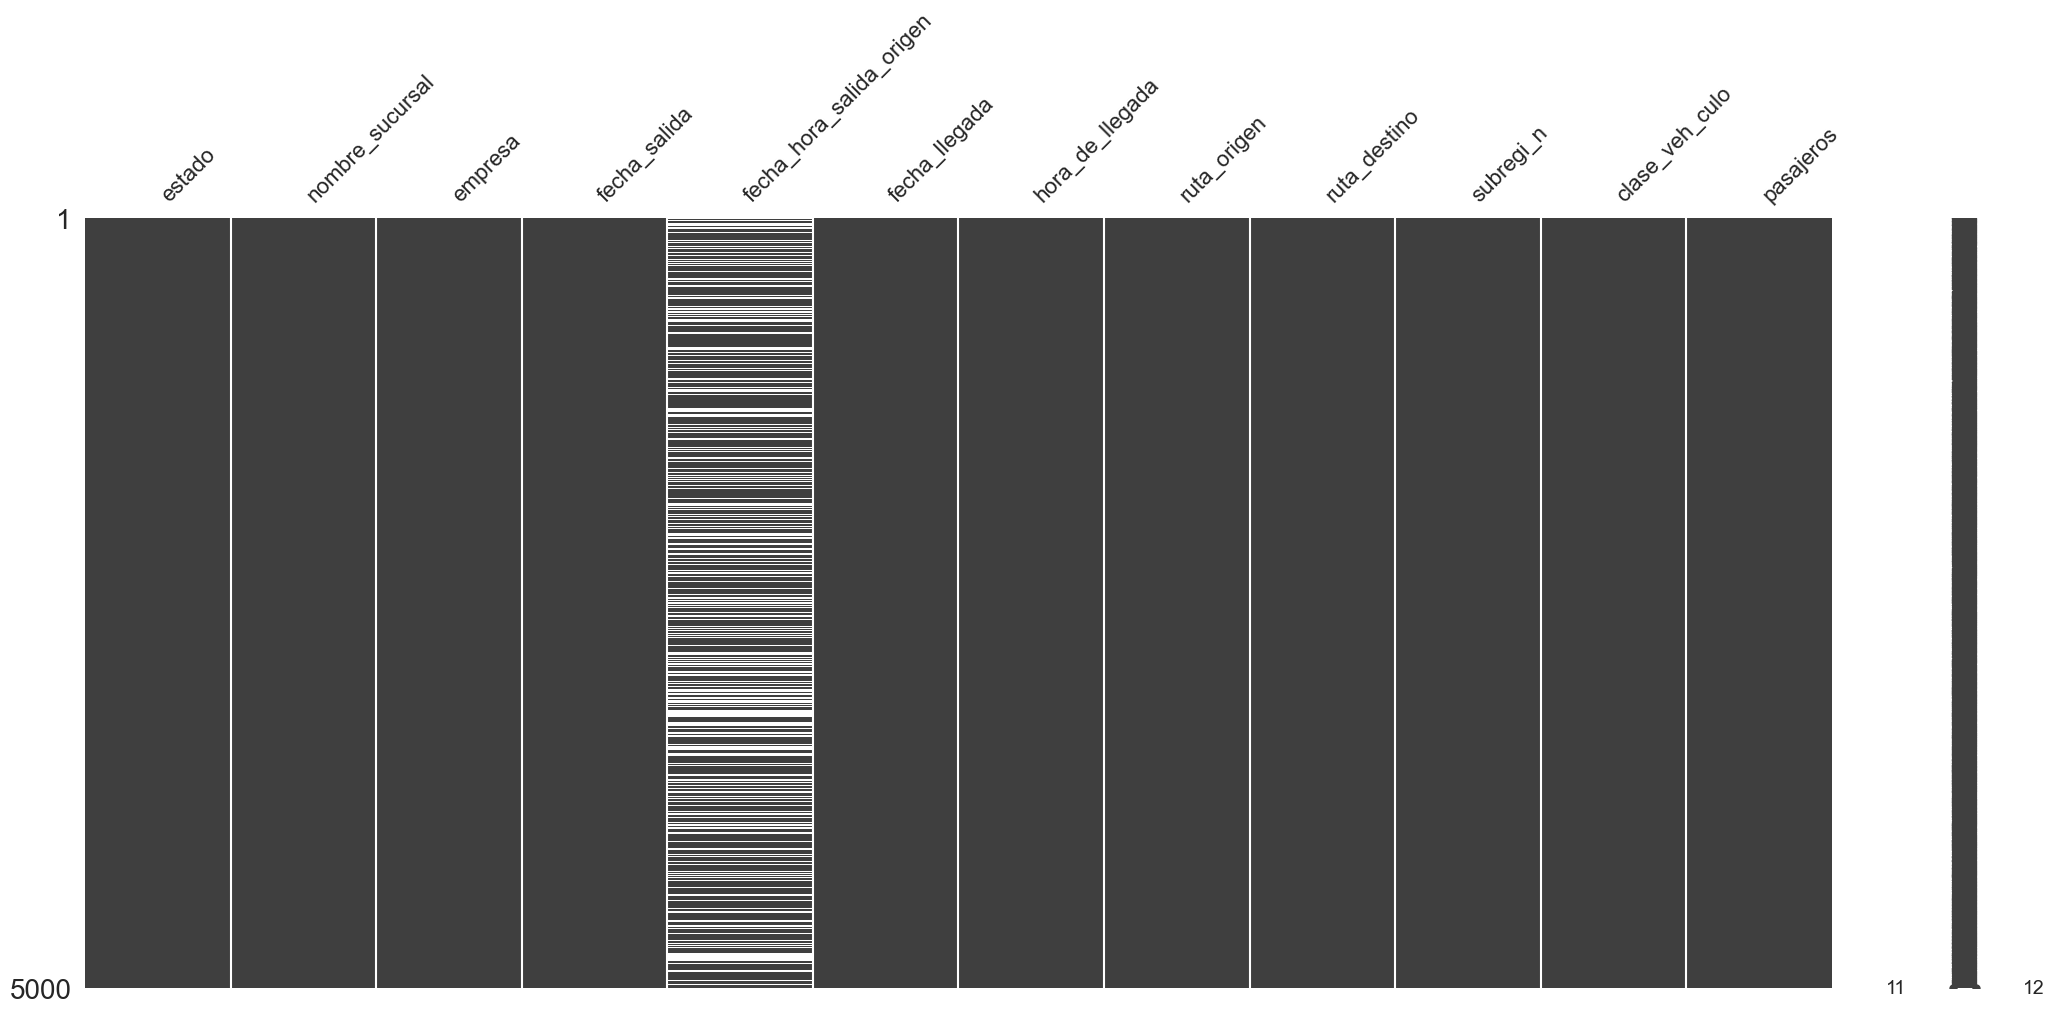

In [10]:
msno.matrix(df.sample(5000, random_state=SEED))   # muestra solo para poder dibujar la matriz
plt.show()


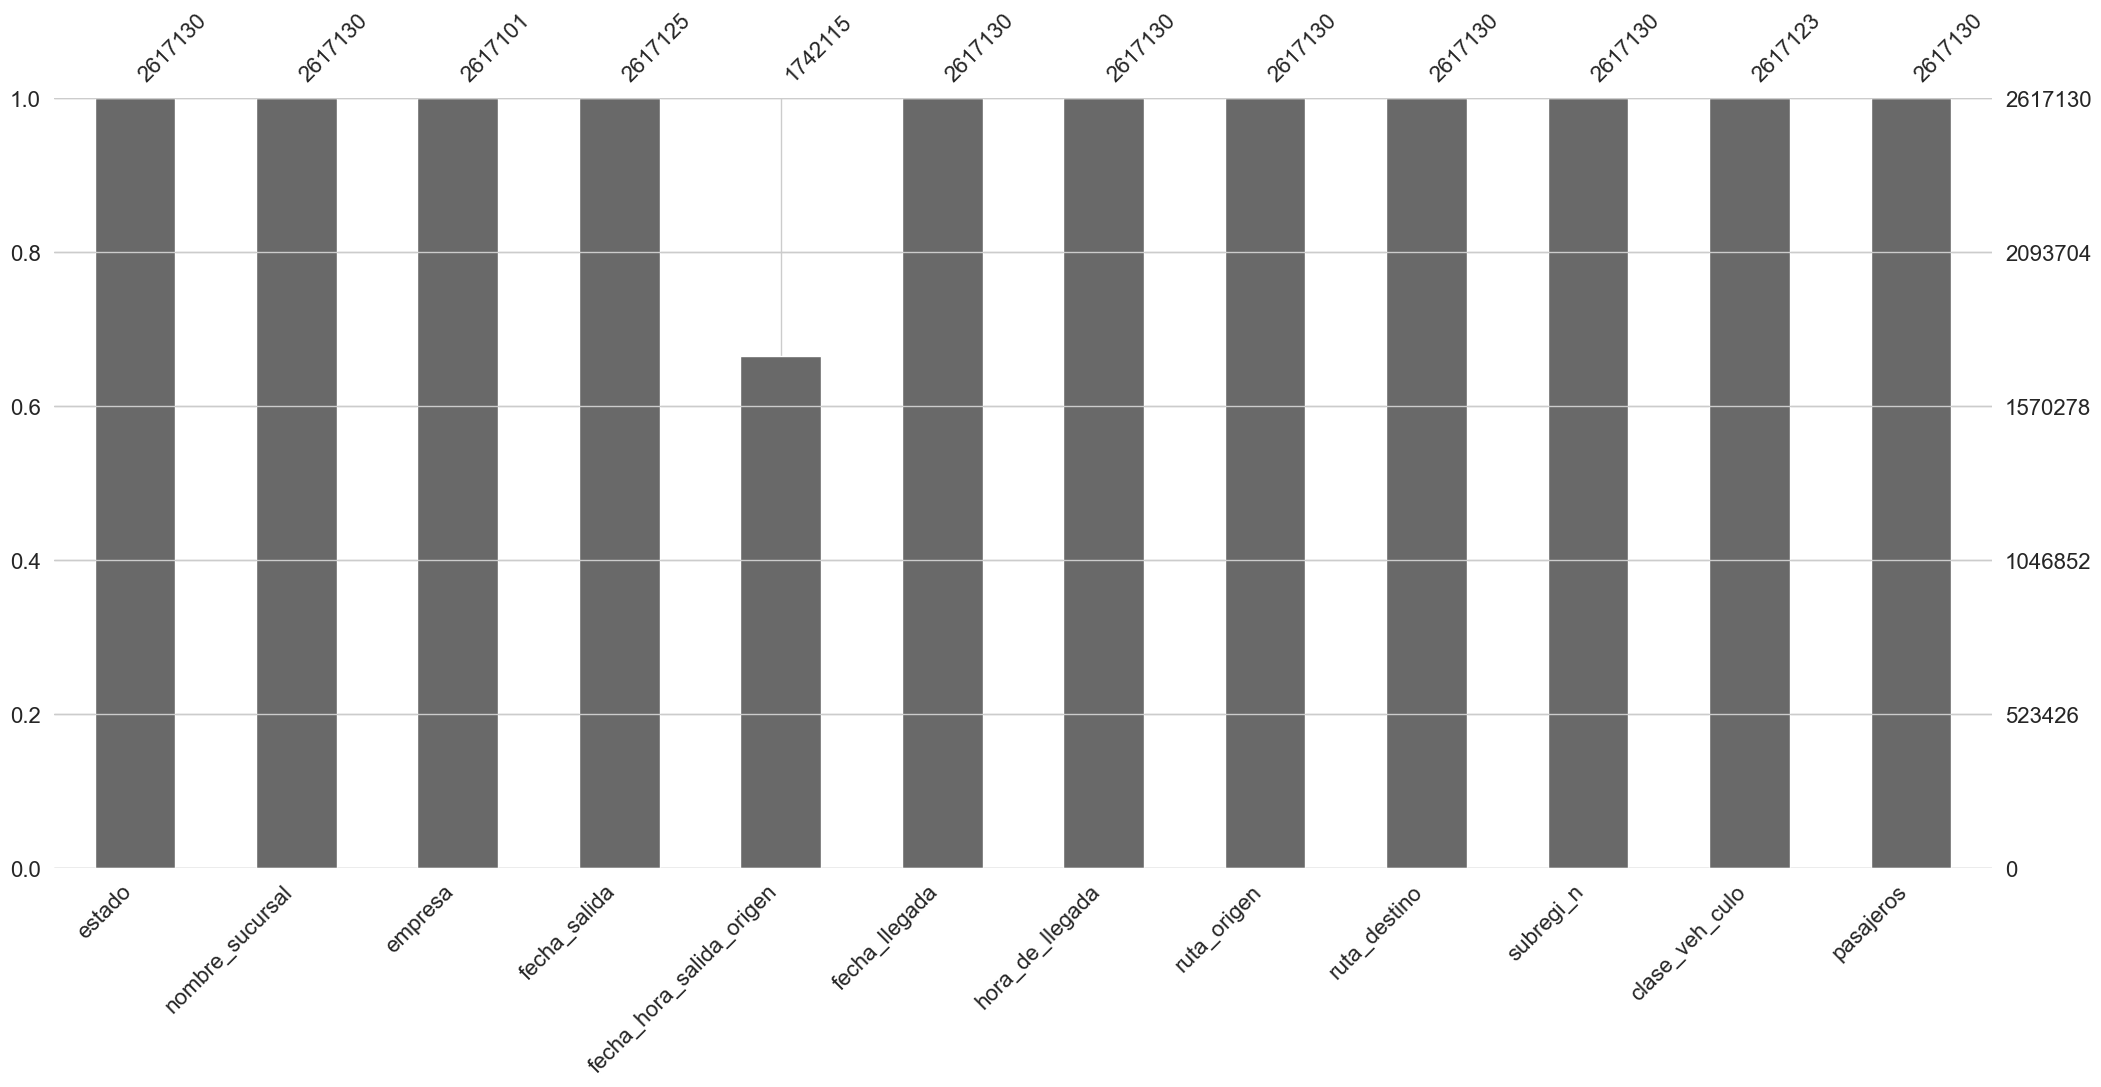

In [11]:
msno.bar(df)
plt.show()


In [12]:
# Porcentaje de filas SIN fecha_hora_salida_origen, por anio y mes (dataset completo)
falta = df["fecha_hora_salida_origen"].isna()
anio = df["fecha_salida"].dt.year.rename("anio")
mes = df["fecha_salida"].dt.month.rename("mes")

por_anio_mes = (falta.groupby([anio, mes]).mean().mul(100).round(1).unstack("mes"))
print("% de filas sin fecha_hora_salida_origen, por anio (filas) y mes (columnas):")
por_anio_mes.reindex([2023, 2024, 2025])


% de filas sin fecha_hora_salida_origen, por anio (filas) y mes (columnas):


mes,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
anio,,,,,,,,,,,,
2023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024,71.1,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
print("% sin fecha_hora_salida_origen, por anio y clase de vehiculo:")
(falta.groupby([anio, df["clase_veh_culo"]], observed=True).mean().mul(100).round(1)
      .unstack("clase_veh_culo").reindex([2023, 2024, 2025]))


% sin fecha_hora_salida_origen, por anio y clase de vehiculo:


clase_veh_culo,AUTOMOVIL,BUS,CAMIONETA,DUO BUS,MICROBUS,bus
anio,,,,,,
2023,0.0,0.0,0.0,0.0,0.0,0.0
2024,97.7,97.3,97.8,96.6,97.5,100.0
2025,0.0,0.0,0.0,0.0,0.0,NaN


**Lectura.** Los nulos de `fecha_hora_salida_origen` no están repartidos al azar sino concentrados en un período:

- **2023 y 2025:** 0% de nulos en todos los meses.
- **2024:** 71.1% en enero y **100% de febrero a diciembre**.
- Por clase de vehículo, en 2024 la proporción es prácticamente la misma (entre 96.6% y 97.8% en todas las clases): no depende de la clase, sino del **período**.

Esto descarta que sea MCAR y corresponde a **MAR** (la ausencia depende de una variable observada: la fecha). Es un cambio de sistema de captura, no una ausencia aleatoria de datos. Consecuencias para el tratamiento: imputar con una media o moda global sería inadecuado (rellenaría todo un año con un valor inventado); lo correcto es sustituir con la otra fuente que, justamente en ese período, sí trae la hora completa (`fecha_salida`), como se ve en el Paso 6.


# FASE B — Derivar y analizar las variables numéricas

Solo ahora, con el dato crudo ya entendido (Fase A), se justifican y construyen las variables numéricas que no vienen dadas.


## Paso 6 — Derivar las variables numéricas

Antes de fijar la fórmula del objetivo, se valida un supuesto que se venía dando por hecho: que `fecha_salida` y `fecha_llegada` traen la fecha **y** la hora real del viaje. Este chequeo es diagnóstico: sigue siendo evidencia, no una decisión de limpieza.


In [14]:
def es_medianoche(s):
    return s == s.dt.normalize()      # NaT -> False


print("% de filas en medianoche (00:00:00), por columna de fecha:")
for c in date_cols:
    print(f"  {c:<28} {es_medianoche(df[c]).mean() * 100:6.2f}%   (nulos: {df[c].isna().mean() * 100:.2f}%)")

mid = es_medianoche(df["fecha_salida"])
print("\nFecha_salida en medianoche, por anio:")
print((mid.groupby(anio).mean() * 100).round(2).reindex([2023, 2024, 2025]))
print("\nFecha_salida en medianoche, por nombre_sucursal (tal como llega):")
print((mid.groupby(df["nombre_sucursal"], observed=True).mean() * 100).round(2))


% de filas en medianoche (00:00:00), por columna de fecha:
  fecha_salida                  65.72%   (nulos: 0.00%)
  fecha_hora_salida_origen       0.05%   (nulos: 33.43%)


  fecha_llegada                 65.69%   (nulos: 0.00%)
  hora_de_llegada                0.01%   (nulos: 0.00%)

Fecha_salida en medianoche, por anio:


anio
2023    100.00
2024      0.08
2025    100.00
Name: fecha_salida, dtype: float64

Fecha_salida en medianoche, por nombre_sucursal (tal como llega):
nombre_sucursal
TERMINAL DEL NORTE      0.08
TERMINAL DEL SUR        0.07
Terminal del Norte    100.00
Terminal del Sur      100.00
Name: fecha_salida, dtype: float64


**Hallazgo:** `fecha_salida` y `fecha_llegada` están truncadas a medianoche (`00:00:00`) en el **65.7%** de las filas: en casi dos de cada tres casos **no** traen la hora real, solo la fecha. En cambio, `fecha_hora_salida_origen` y `hora_de_llegada` casi nunca están en medianoche (0.05% y 0.01%).

El patrón coincide exactamente con el período y con la escritura de `nombre_sucursal`:
- **2023 y 2025** (100% en medianoche) y terminal escrita en formato mixto ("Terminal del Norte"): `fecha_salida` y `fecha_llegada` solo guardan la fecha; la hora real vive en `fecha_hora_salida_origen` y `hora_de_llegada`.
- **2024** (0.08% en medianoche) y terminal escrita en mayúsculas ("TERMINAL DEL NORTE"): `fecha_salida` y `fecha_llegada` sí traen la hora completa, y `fecha_hora_salida_origen` casi no se diligencia (Paso 5).

Son **dos sistemas o convenciones de captura distintos**, y en cada período la columna que falta o está truncada es justo la que la otra convención sí llena.

**Consecuencia:** calcular `fecha_llegada - fecha_salida` directamente da una duración de `0` para el 65.7% de los viajes: no es una medida real, es un artefacto del formato de captura. La corrección:

- **Salida real:** `fecha_hora_salida_origen` si existe; si no, `fecha_salida` como respaldo (`fillna`).
- **Llegada real:** `hora_de_llegada` (0% de nulos, casi nunca en medianoche).

```
salida_real = fecha_hora_salida_origen.fillna(fecha_salida)
llegada_real = hora_de_llegada
duracion_viaje_horas = (llegada_real - salida_real) en horas
```

**Esto no es imputación estadística.** No se "adivina" el valor faltante con una media, mediana o moda; se sustituye con la otra columna que, en esos casos, ya tiene el dato real capturado por la otra convención. Tras la corrección, solo el 0.073% de las filas queda en medianoche (probablemente salidas reales a las 00:00) y únicamente 5 filas no tienen ninguna hora de salida.

`hora_salida_decimal`, `dia_semana` y `mes` se derivan también de `salida_real` (no de `fecha_salida` sin corregir, que daría una hora de salida `00:00` falsa en dos de cada tres filas). La verificación lo respalda: en las 1.742.115 filas donde existen ambas columnas, el día calendario coincide en el 100% de los casos, así que la fecha es igual de confiable en ambas convenciones.

**Justificación de las variables derivadas:**
- **`duracion_viaje_horas`** (objetivo): la fórmula anterior.
- **`hora_salida_decimal`** (por ejemplo `14.5` para las 2:30 pm): un instante completo no es comparable entre viajes; lo que razonablemente influye en la duración es la hora del día (tráfico, viajes nocturnos de larga distancia). Se guarda en decimal, y no como entero, para no perder la precisión de los minutos.
- **`dia_semana`** (0 = lunes … 6 = domingo): permite capturar diferencias entre días laborales y fines de semana.
- **`mes`** (1-12): permite capturar estacionalidad (temporadas, festivos, lluvias).

Son transformaciones mecánicas y justificadas sobre columnas ya entendidas, no decisiones de limpieza (como eliminar una columna), por eso no requieren la misma evidencia previa.


In [15]:
salida_real = df["fecha_hora_salida_origen"].fillna(df["fecha_salida"])
llegada_real = df["hora_de_llegada"]

df["duracion_viaje_horas"] = (llegada_real - salida_real).dt.total_seconds() / 3600
df["hora_salida_decimal"] = salida_real.dt.hour + salida_real.dt.minute / 60
df["dia_semana"] = salida_real.dt.dayofweek      # 0 = lunes
df["mes"] = salida_real.dt.month
df["anio_salida"] = salida_real.dt.year          # solo para diagnostico, no es predictora

print(f"% en medianoche tras la correccion (salida_real): {es_medianoche(salida_real).mean() * 100:.3f}%")
print(f"Filas sin salida_real (ni fecha_hora_salida_origen ni fecha_salida): {int(salida_real.isna().sum())}")

# Verificacion: cuando ambas columnas existen, ¿la fecha (dia calendario) coincide?
ambas = df["fecha_hora_salida_origen"].notna() & df["fecha_salida"].notna()
coincide = (df.loc[ambas, "fecha_hora_salida_origen"].dt.normalize()
            == df.loc[ambas, "fecha_salida"].dt.normalize()).mean() * 100
print(f"Filas con ambas columnas: {int(ambas.sum()):,}; el dia calendario coincide en {coincide:.2f}%")

num_cols = ["pasajeros", "duracion_viaje_horas", "hora_salida_decimal", "dia_semana", "mes"]
df[num_cols].head()


% en medianoche tras la correccion (salida_real): 0.073%
Filas sin salida_real (ni fecha_hora_salida_origen ni fecha_salida): 5


Filas con ambas columnas: 1,742,115; el dia calendario coincide en 100.00%


,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana,mes
0,8,6.450000,18.00,6.0,12.0
1,15,7.933333,18.50,6.0,12.0
2,40,9.450000,18.50,6.0,12.0
3,35,8.633333,19.75,6.0,12.0
4,10,8.616667,20.00,6.0,12.0


In [16]:
print("Filas por anio y mes de salida (2023-2025):")
display(pd.crosstab(df["anio_salida"], df["mes"]).reindex([2023, 2024, 2025]))

# Fecha de salida incompatible con la de llegada: el anio de salida deberia ser el de llegada o el anterior
anio_llegada = df["hora_de_llegada"].dt.year
incompatible = ~(anio_llegada - df["anio_salida"]).between(0, 1)
print(f"\nFilas cuya fecha de salida es incompatible con la de llegada (o no existe): {int(incompatible.sum())}")
print("Anios de salida de esas filas:", sorted(df.loc[incompatible, "anio_salida"].dropna().astype(int).unique().tolist()))
print(f"Filas con salida a finales de 2022 y llegada en 2023 (viajes legitimos, no se cuentan como error): "
      f"{int(((df['anio_salida'] == 2022) & (anio_llegada == 2023)).sum())}")
df.loc[incompatible, ["fecha_salida", "fecha_hora_salida_origen", "hora_de_llegada", "duracion_viaje_horas"]].sort_values("hora_de_llegada").head(12)


Filas por anio y mes de salida (2023-2025):


mes,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
anio_salida,,,,,,,,,,,,
2023,2112,62976,70518,70023,73046,73745,76001,75569,72013,75504,72987,79793
2024,79088,68585,76358,71022,74090,75390,75921,76036,68601,75549,74500,82760
2025,80571,67969,75271,74112,73439,76593,77326,78284,76495,77981,75455,81402



Filas cuya fecha de salida es incompatible con la de llegada (o no existe): 39
Anios de salida de esas filas: [2002, 2003, 2004, 2006, 2007, 2009, 2010, 2011, 2012, 2029]
Filas con salida a finales de 2022 y llegada en 2023 (viajes legitimos, no se cuentan como error): 6


,fecha_salida,fecha_hora_salida_origen,hora_de_llegada,duracion_viaje_horas
1038600,NaT,NaT,2023-04-03 06:41:00,NaN
1261839,NaT,NaT,2023-07-05 09:53:00,NaN
1416874,2009-06-07,2009-06-07 16:00:00,2023-09-07 09:31:00,124913.516667
1469026,2009-08-02,2009-08-02 17:00:00,2023-09-29 07:07:00,124094.116667
1469037,2009-08-02,2009-08-02 21:00:00,2023-09-29 07:13:00,124090.216667
1498223,NaT,NaT,2023-10-11 05:59:00,NaN
1514395,2010-06-17,2010-06-17 16:00:00,2023-10-17 06:45:00,116870.750000
1515496,2010-06-01,2010-06-01 15:30:00,2023-10-17 13:38:00,117262.133333
1561663,2011-11-05,2011-11-05 21:00:00,2023-11-06 06:17:00,105201.283333
1573828,2011-11-01,2011-11-01 21:00:00,2023-11-11 05:32:00,105416.533333


**Lectura:**
- **Cobertura mensual:** desde febrero de 2023 cada mes tiene entre 63.000 y 83.000 filas, sin huecos. Enero de 2023 tiene solo 2.112 filas: los datos útiles empiezan en febrero de 2023. Ya no hay sesgo por concentrarse en unos pocos meses, por lo que `mes` y la estacionalidad sí pueden analizarse.
- **Fechas de salida imposibles:** 39 filas tienen una fecha de salida incompatible con la de llegada (el año de salida debería ser el de llegada o el anterior) o directamente no la tienen. De ellas, 34 tienen año 2002-2012 o 2029, que parecen errores de digitación del año (por ejemplo, salida en 2009 y llegada en 2023), y 5 no tienen ninguna hora de salida. Los 6 viajes con salida a finales de 2022 y llegada en 2023 son legítimos y no cuentan como error. Estas filas producen duraciones absurdas (decenas de miles de horas) que se tratan junto con las demás duraciones inválidas.


## Paso 7 — Inspeccionar las columnas numéricas (*Inspect numeric columns*)

Estadísticas descriptivas de las cinco variables numéricas. Más que calcularlas, importa **qué implica cada una para el análisis y el modelado**, y eso se discute después de los resultados.


In [17]:
df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pasajeros,2617130.0,10.143494,9.450293,0.000000,1.000000,1.000000,4.000000,7.000000,13.000000,30.000000,42.0,259.000000
duracion_viaje_horas,2617125.0,5.237335,496.432176,-52620.533333,0.783333,0.966667,1.283333,1.983333,3.966667,11.316667,18.1,192858.300000
hora_salida_decimal,2617125.0,12.138547,4.791913,0.000000,4.000000,5.000000,8.000000,12.000000,16.000000,20.000000,22.0,23.983333
dia_semana,2617125.0,3.018059,2.018843,0.000000,0.000000,0.000000,1.000000,3.000000,5.000000,6.000000,6.0,6.000000
mes,2617125.0,6.730078,3.388312,1.000000,1.000000,1.000000,4.000000,7.000000,10.000000,12.000000,12.0,12.000000


In [18]:
resumen_sesgo = pd.DataFrame({
    "media": df[num_cols].mean(),
    "mediana": df[num_cols].median(),
    "desv_estandar": df[num_cols].std(),
    "asimetria (skew)": df[num_cols].skew(),
}).round(3)
resumen_sesgo


,media,mediana,desv_estandar,asimetria (skew)
pasajeros,10.143,7.000,9.450,1.779
duracion_viaje_horas,5.237,1.983,496.432,298.257
hora_salida_decimal,12.139,12.000,4.792,0.084
dia_semana,3.018,3.000,2.019,-0.030
mes,6.730,7.000,3.388,-0.045


In [19]:
# ¿Hay conteos de pasajeros imposibles para la capacidad de cada clase de vehiculo?
g = df.groupby(df["clase_veh_culo"].astype(str).str.upper())["pasajeros"]
pd.DataFrame({"filas": g.size(), "mediana": g.median(), "p99": g.quantile(.99), "p99.9": g.quantile(.999), "max": g.max()})


,filas,mediana,p99,p99.9,max
clase_veh_culo,,,,,
AUTOMOVIL,40192,2.0,4.0,5.0,9
BUS,1323373,10.0,42.0,50.0,259
CAMIONETA,525980,5.0,8.0,9.0,38
DUO BUS,11130,35.0,60.0,62.0,64
MICROBUS,716448,7.0,19.0,19.0,41


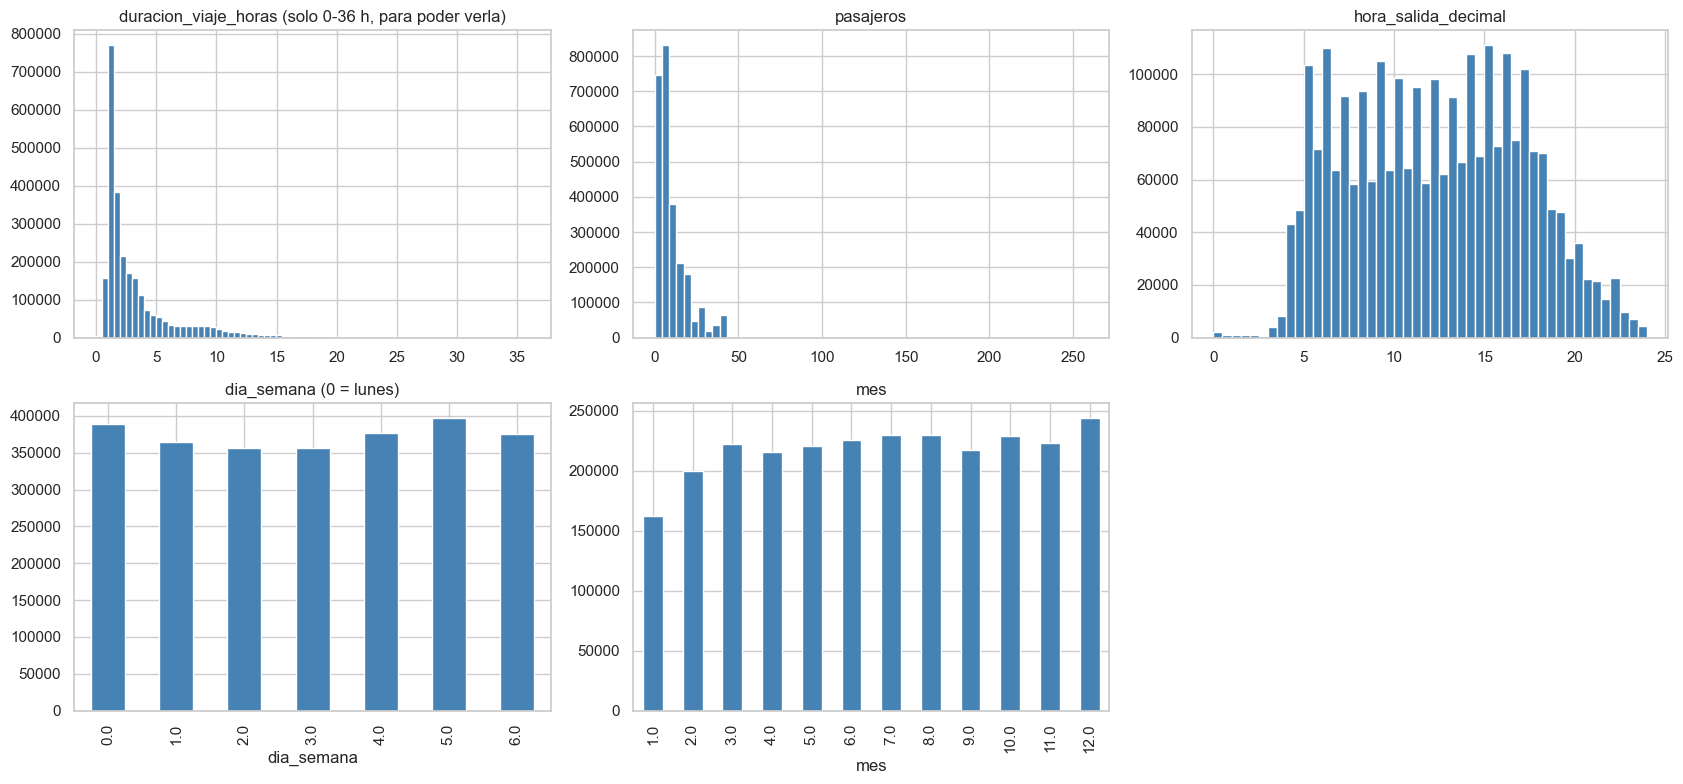

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
ok_hist = df["duracion_viaje_horas"].between(0, 36)
axes[0, 0].hist(df.loc[ok_hist, "duracion_viaje_horas"], bins=72, color="steelblue")
axes[0, 0].set_title("duracion_viaje_horas (solo 0-36 h, para poder verla)")
axes[0, 1].hist(df["pasajeros"], bins=60, color="steelblue")
axes[0, 1].set_title("pasajeros")
axes[0, 2].hist(df["hora_salida_decimal"], bins=48, color="steelblue")
axes[0, 2].set_title("hora_salida_decimal")
df["dia_semana"].value_counts().sort_index().plot.bar(ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("dia_semana (0 = lunes)")
df["mes"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("mes")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


### Duraciones que no tienen sentido: ¿cómo distinguir un error de un viaje largo real?

El objetivo contiene valores imposibles (negativos) y otros extremos. Antes de decidir cómo tratarlos, hay que entender qué son. Se comparan tres criterios posibles (sin aplicar ninguno todavía):

- **(a) Regla del IQR global:** fuera de `Q1 − 1.5·IQR` a `Q3 + 1.5·IQR` de *todas* las duraciones.
- **(b) Corte fijo:** menor que 0 o mayor que 24 horas.
- **(c) Criterio por ruta:** menor que 0, o mayor que la duración típica (mediana) **de su propia ruta** más 12 horas.


In [21]:
dur = df["duracion_viaje_horas"]
print(f"Duraciones calculables: {dur.notna().sum():,}")
print(f"Negativas: {(dur < 0).sum():,}")
print("\nDuraciones mayores a 24 h, por tramo:")
print(pd.cut(dur[dur > 24], bins=[24, 30, 36, 48, 72, 168, np.inf]).value_counts().sort_index())


Duraciones calculables: 2,617,125
Negativas: 118

Duraciones mayores a 24 h, por tramo:
duracion_viaje_horas
(24.0, 30.0]     3700
(30.0, 36.0]      612
(36.0, 48.0]      157
(48.0, 72.0]       48
(72.0, 168.0]      38
(168.0, inf]      193
Name: count, dtype: int64


In [22]:
# Rutas detras de los viajes de 24-36 h, con su duracion tipica usando TODAS sus filas
largas = df.loc[(dur > 24) & (dur <= 36), "ruta_origen"].value_counts().head(10).index
g = df[df["ruta_origen"].isin(largas)].groupby("ruta_origen", observed=True)["duracion_viaje_horas"]
pd.DataFrame({"filas": g.size(), "mediana": g.median(), "p90": g.quantile(.9), "max": g.max()}).round(1)


,filas,mediana,p90,max
ruta_origen,,,,
BOGOTA,30235,10.8,13.0,125676.6
CARTAGENA,7320,14.8,17.8,184341.3
CUCUTA,12949,15.9,18.7,153375.7
IPIALES,2736,21.1,25.5,453.3
IPIALES-MEDELLIN,1090,20.4,23.4,188.0
MAICAO,6374,20.5,24.6,124913.5
MAICAO-MEDELLIN,3788,20.7,24.8,69.6
MOCOA,921,22.6,26.7,772.0
MOCOA-MEDELLIN,459,22.7,27.8,769.6


In [23]:
# Mediana por ruta (solo con filas plausibles para que los errores no la contaminen)
plausible = dur.between(0, 72)
tab = df[plausible].groupby("ruta_origen", observed=True)["duracion_viaje_horas"].agg(["median", "count"])
med_ruta = {str(k): v for k, v in tab["median"].where(tab["count"] >= 30).dropna().items()}
med_global = dur[plausible].median()
ref_ruta = df["ruta_origen"].astype(str).map(med_ruta).fillna(med_global)

q1, q3 = dur.quantile([.25, .75])
iqr = q3 - q1
flag_a = (dur < q1 - 1.5 * iqr) | (dur > q3 + 1.5 * iqr)
flag_b = (dur < 0) | (dur > 24)
flag_c = (dur < 0) | (dur > ref_ruta + 12)

largo_real = (dur > 24) & (dur <= 36)        # tramo donde estan las rutas largas legitimas
comparacion = pd.DataFrame({
    "filas marcadas": [flag_a.sum(), flag_b.sum(), flag_c.sum()],
    "% del total": [flag_a.mean() * 100, flag_b.mean() * 100, flag_c.mean() * 100],
    "de ellas, entre 24 y 36 h": [(flag_a & largo_real).sum(), (flag_b & largo_real).sum(), (flag_c & largo_real).sum()],
}, index=["(a) IQR global", "(b) corte fijo 24 h", "(c) por ruta (mediana + 12 h)"])
comparacion.round(3)


,filas marcadas,% del total,"de ellas, entre 24 y 36 h"
(a) IQR global,298757,11.415,4312
(b) corte fijo 24 h,4866,0.186,4312
(c) por ruta (mediana + 12 h),3782,0.145,1397


### Qué implican estos estadísticos para el análisis y el modelado

Los estadísticos descriptivos no son un fin en sí mismo: cada uno orienta una decisión. Con los resultados de este notebook:

| Estadístico | Qué se observa | Qué implica |
|---|---|---|
| **Media vs. mediana** de la duración | Media 5.24 h, mediana 1.98 h | La media está contaminada por unos pocos valores imposibles; la **mediana** es el resumen representativo. Por eso la mediana es la elección natural para reemplazar valores inválidos (una media arrastraría los errores) y para el modelo de referencia (*baseline*) |
| **Desviación estándar** | 496 h con todos los datos; 3.6 h al excluir las duraciones inválidas | Unas pocas decenas de filas con año imposible (duraciones de decenas de miles de horas) bastan para multiplicar por más de 100 la dispersión aparente. Con la desviación inflada, métricas como el R² (que compara el error del modelo con la varianza del objetivo) o el RMSE (que castiga los errores grandes) se distorsionan: **hay que limpiar el objetivo antes de evaluar** |
| **Asimetría** (*skew*) | 298 con todos los datos; 2.4 tras excluir las inválidas | Aun sin errores, la cola derecha es larga (p50 = 2.0 h, p95 = 11.3 h, p99 = 18.1 h) porque conviven rutas de 1 hora con rutas de 20 horas. Un modelo lineal se ve afectado por esa cola; los modelos de árboles son más robustos; si importara el error relativo, podría predecirse el logaritmo de la duración |
| **Percentiles / IQR** | p25 = 1.28 h, p75 = 3.97 h; la regla de Tukey global (Q3 + 1.5·IQR) da un límite de unas 8 h | La regla del IQR trata como atípico todo lo que pasa de ~8 h, es decir, el 11.4% de los viajes, incluyendo las rutas largas legítimas (Maicao, Cúcuta, Bogotá...). El IQR global no sirve aquí porque la población mezcla rutas muy distintas: hace falta un criterio **por ruta** (ver más abajo) |
| **Mínimo y máximo** | Duración de -52.620 h a 192.858 h; `pasajeros` hasta 259 | Revelan valores imposibles que exigen tratamiento. Los conteos de pasajeros imposibles para la capacidad del vehículo son casi inexistentes (unas 7 filas de 2,6 millones) |
| **Escalas** | `pasajeros` 0-259, hora 0-24, día 0-6, mes 1-12 | Los modelos que dependen de distancias o gradientes (regresión regularizada, SVM, KNN, redes neuronales) necesitan escalar las variables (ajustando el escalado solo con el entrenamiento); los árboles no. Además `dia_semana` y `mes` son cíclicos: tratarlos como números impone un orden artificial (¿diciembre está "lejos" de enero?) |
| **Media y mediana de hora, día y mes** | Hora: 12.1 / 12.0; día: 3.0 / 3; mes: 6.7 / 7 | Distribuciones casi uniformes y simétricas: los viajes cubren todo el ciclo diario, semanal y anual, sin sesgo de cobertura |

### Duraciones que no tienen sentido: ¿cómo distinguir un error de un viaje largo real?

- **Negativas:** 118 filas (imposibles: llegar antes de salir).
- **Mayores a 24 h:** 4.716 filas, pero **no son todas errores**: 3.700 están entre 24 y 30 h y 612 entre 30 y 36 h, y provienen de rutas genuinamente largas. La tabla de rutas muestra, por ejemplo, que Mocoa (mediana 22.6 h, p90 26.7 h), Maicao (20.5 h, p90 24.6 h) o Ipiales (21.1 h, p90 25.5 h) tienen viajes reales de más de 24 horas. Solo unas pocas filas (menos de 250) superan las 48 h, y esas sí son errores evidentes (por ejemplo, un Bogotá-Medellín de cientos de horas).

Comparación de los tres criterios:

- **(a) IQR global** marcaría 298.757 filas (**11.4%**): descartaría uno de cada nueve viajes.
- **(b) Corte fijo de 24 h** marcaría 4.866 filas, de las cuales **4.312 (89%) están entre 24 y 36 h**: eliminaría o "corregiría" viajes largos legítimos y haría que el modelo subestimara sistemáticamente las rutas largas.
- **(c) Criterio por ruta** (negativa, o más de 12 h por encima de la mediana de su ruta) marca 3.782 filas (**0.145%**): las negativas, los extremos y los desfases de días completos, sin tocar los viajes largos de rutas largas. Las 1.397 filas del tramo 24-36 h que sí marca pertenecen a rutas cuya duración típica es mucho menor, así que es improbable que sean viajes legítimos.

El criterio (c) es el que se propone usar en la preparación de datos. El umbral de 12 horas no toca los retrasos reales (un viaje demorado sigue siendo información valiosa para el modelo) pero sí captura los desfases de un día completo (±24 h), que son la firma de los errores de fecha observados.


## Paso 8 — Correlaciones (*correlations*)

Matriz de correlación entre las variables numéricas. Se calcula sobre las filas cuya duración es válida según el criterio (c) del paso anterior, porque un puñado de valores extremos (de cientos de horas) distorsiona por completo el coeficiente de Pearson. Se incluye también la correlación de Spearman (basada en rangos, menos sensible a extremos y capaz de detectar relaciones monótonas no lineales).


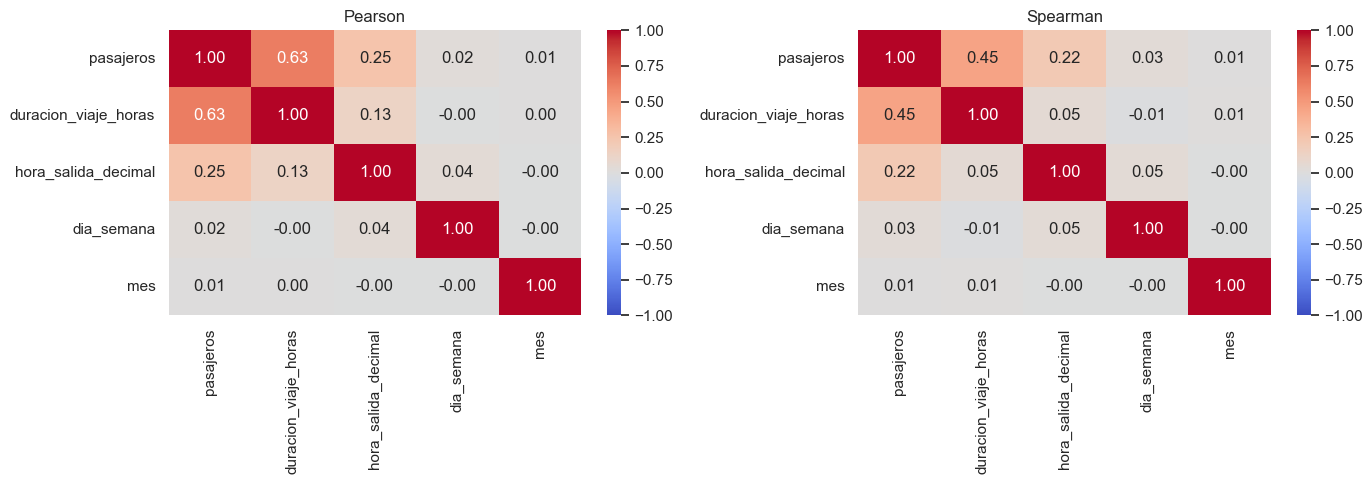

Pearson:


,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana,mes
pasajeros,1.000,0.628,0.252,0.025,0.006
duracion_viaje_horas,0.628,1.000,0.126,-0.004,0.004
hora_salida_decimal,0.252,0.126,1.000,0.045,-0.004
dia_semana,0.025,-0.004,0.045,1.000,-0.001
mes,0.006,0.004,-0.004,-0.001,1.000


Spearman:


,pasajeros,duracion_viaje_horas,hora_salida_decimal,dia_semana,mes
pasajeros,1.000,0.452,0.216,0.033,0.008
duracion_viaje_horas,0.452,1.000,0.049,-0.011,0.009
hora_salida_decimal,0.216,0.049,1.000,0.046,-0.004
dia_semana,0.033,-0.011,0.046,1.000,-0.001
mes,0.008,0.009,-0.004,-0.001,1.000


In [24]:
ok = dur.notna() & ~flag_c
corr_p = df.loc[ok, num_cols].corr(method="pearson")
corr_s = df.loc[ok, num_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.show()
print("Pearson:")
display(corr_p.round(3))
print("Spearman:")
display(corr_s.round(3))


In [25]:
# ¿La relacion pasajeros-duracion se mantiene dentro de cada clase de vehiculo?
por_clase = (df[ok].groupby("clase_veh_culo", observed=True)
             .apply(lambda g: pd.Series({"filas": len(g),
                                         "corr(pasajeros, duracion)": g["pasajeros"].corr(g["duracion_viaje_horas"]),
                                         "pasajeros mediana": g["pasajeros"].median()}),
                    include_groups=False))
por_clase.round(3)


,filas,"corr(pasajeros, duracion)",pasajeros mediana
clase_veh_culo,,,
AUTOMOVIL,40174.0,0.019,2.0
BUS,1320663.0,0.625,10.0
CAMIONETA,525605.0,-0.015,5.0
DUO BUS,11046.0,0.050,35.0
MICROBUS,715844.0,0.185,7.0
bus,4.0,0.671,10.0


In [26]:
# ¿La relacion pasajeros-duracion se debe a la ruta? Correlacion DENTRO de cada ruta (solo BUS)
bus = df[ok & (df["clase_veh_culo"].astype(str).str.upper() == "BUS")]
filas = []
for ruta, g in bus.groupby("ruta_origen", observed=True):
    if len(g) >= 500 and g["pasajeros"].std() > 0 and g["duracion_viaje_horas"].std() > 0:
        filas.append((ruta, len(g), g["pasajeros"].corr(g["duracion_viaje_horas"])))
intra = pd.DataFrame(filas, columns=["ruta", "viajes", "corr"])
print(f"Correlacion global pasajeros-duracion en BUS: {bus['pasajeros'].corr(bus['duracion_viaje_horas']):.3f}")
print(f"Correlacion promedio DENTRO de cada ruta ({len(intra)} rutas con >=500 viajes, ponderada por viajes): "
      f"{np.average(intra['corr'], weights=intra['viajes']):.3f}")
intra.sort_values("viajes", ascending=False).head(8).round(3)


Correlacion global pasajeros-duracion en BUS: 0.625
Correlacion promedio DENTRO de cada ruta (272 rutas con >=500 viajes, ponderada por viajes): 0.007


,ruta,viajes,corr
195,RIONEGRO,73991,-0.095
146,MARINILLA,55921,-0.007
110,GUARNE,46327,0.020
196,RIONEGRO-MEDELLIN,40496,-0.095
128,LA CEJA,29420,0.117
147,MARINILLA-MEDELLIN,29048,-0.018
91,EL RETIRO,28821,0.145
40,BOGOTA,27843,-0.120


**Lectura de las correlaciones** (sobre las filas con duración válida según el criterio (c)):

- `pasajeros` – `duracion_viaje_horas`: **0.63** (Pearson) y 0.45 (Spearman). Es la correlación más alta de la matriz.
- `hora_salida_decimal` – `pasajeros`: 0.25; `hora_salida_decimal` – `duracion_viaje_horas`: 0.13 (Spearman 0.05).
- `dia_semana` y `mes`: prácticamente **cero** con todas las demás variables (|r| ≤ 0.05).
- Ningún par de predictoras supera 0.8, así que **no hay redundancia fuerte entre las variables numéricas** y no hay razón para eliminar ninguna por correlación.

**Cómo interpretarlas correctamente:**

1. **La relación pasajeros-duración se debe a la ruta, no a que más pasajeros alarguen el viaje.** La correlación se concentra en los BUS (0.63; en MICROBUS 0.19; en CAMIONETA, AUTOMOVIL y DUO BUS es ~0). Pero **dentro de cada ruta**, la correlación promedio (272 rutas con al menos 500 viajes de BUS) es de apenas **0.007**: las rutas largas usan buses más grandes y llenos, y esa diferencia entre rutas produce la correlación global. Es un buen ejemplo de que correlación no implica causalidad y de que una correlación global puede ser un efecto de confusión. Para el modelado significa que `pasajeros` aporta poca información adicional una vez que se conoce la ruta, y que, aun si el conteo incluyera pasajeros que abordan en ruta, no se observa dependencia con la duración dentro de una misma ruta (relevante para el análisis de fuga de información).
2. **Correlación cercana a cero no significa "sin efecto".** Pearson mide solo relaciones lineales: `dia_semana` y `mes` casi no se correlacionan con la duración, y `hora_salida_decimal` solo débilmente, pero el Paso 9 muestra que la hora sí tiene un efecto fuerte, aunque no lineal.


## Paso 9 — Relación de las variables predictoras con la variable objetivo

La correlación solo cubre variables numéricas. Para las categóricas y para las variables temporales se compara la **distribución de la duración por grupo** (mediana y rango intercuartílico, robustos a valores extremos), sobre las filas con duración válida.


In [27]:
def resumen_por(clave, top=None):
    g = df.loc[ok, "duracion_viaje_horas"].groupby(clave, observed=True)
    t = pd.DataFrame({"filas": g.size(), "p25": g.quantile(.25), "mediana": g.median(), "p75": g.quantile(.75)})
    t = t.sort_values("filas", ascending=False)
    return t.head(top).round(2) if top else t.round(2)


print("== Por clase de vehiculo ==")
display(resumen_por(df.loc[ok, "clase_veh_culo"]))
print("== Por terminal (normalizando mayusculas) ==")
display(resumen_por(df.loc[ok, "nombre_sucursal"].astype(str).str.upper()))
print("== Por subregion (normalizando mayusculas) ==")
display(resumen_por(df.loc[ok, "subregi_n"].astype(str).str.upper()))
print("== 10 empresas con mas viajes ==")
display(resumen_por(df.loc[ok, "empresa"], top=10))
print("== 10 rutas de origen con mas viajes ==")
display(resumen_por(df.loc[ok, "ruta_origen"], top=10))


== Por clase de vehiculo ==


,filas,p25,mediana,p75
clase_veh_culo,,,,
BUS,1320663,1.50,2.83,6.78
MICROBUS,715844,1.37,1.83,2.95
CAMIONETA,525605,1.05,1.23,1.97
AUTOMOVIL,40174,1.98,2.50,3.00
DUO BUS,11046,9.25,11.32,13.07
bus,4,6.94,7.07,7.91


== Por terminal (normalizando mayusculas) ==


,filas,p25,mediana,p75
nombre_sucursal,,,,
TERMINAL DEL NORTE,1909099,1.25,1.82,3.63
TERMINAL DEL SUR,704244,1.53,2.57,4.62


== Por subregion (normalizando mayusculas) ==


,filas,p25,mediana,p75
subregi_n,,,,
ORIENTE,1024000,1.13,1.38,1.90
NORTE,772446,1.67,2.77,6.81
SUR,411272,2.40,3.42,5.77
OCCIDENTE,234098,1.10,1.38,2.93
CENTRO,171527,1.43,4.48,5.70


== 10 empresas con mas viajes ==


,filas,p25,mediana,p75
empresa,,,,
COOPETRANSA,189523,1.23,1.57,2.08
COONORTE,168719,3.00,3.82,6.10
RAPIDO MEDELLIN RIONEGRO S.A.,143637,1.02,1.15,1.35
SOTRAURABA,120588,1.13,1.45,2.92
TRANSUNIDOS,110359,1.45,1.62,1.98
TRANS GOMEZ HERNANDEZ,109838,1.05,1.30,4.13
EXPRE - BELMIRA S.A.,104719,1.27,1.52,2.30
TRANSORIENTE,87868,1.25,1.42,3.28
SOTRAMAR,84973,1.05,1.13,1.27


== 10 rutas de origen con mas viajes ==


,filas,p25,mediana,p75
ruta_origen,,,,
RIONEGRO,214510,1.02,1.17,1.38
RIONEGRO-MEDELLIN,113625,1.07,1.22,1.45
SAN PEDRO DE LOS MILAGROS,100050,1.12,1.23,1.40
MARINILLA,61746,1.03,1.12,1.25
SANTA FE DE ANTIOQUIA,60716,1.08,1.20,1.40
LA CEJA,58427,1.43,1.55,1.73
SAN PEDRO DE LOS MILAGROS-MEDELLIN,52788,1.18,1.32,1.48
GUARNE,46335,0.83,0.93,1.07
EL SANTUARIO,42899,1.20,1.30,1.43


In [28]:
# Cuanto varia la duracion tipica entre empresas y entre rutas (grupos con al menos 1.000 viajes)
for col in ["empresa", "ruta_origen"]:
    t = resumen_por(df.loc[ok, col])
    t = t[t["filas"] >= 1000]
    print(f"{col}: {len(t)} grupos con >=1.000 viajes; mediana de duracion entre "
          f"{t['mediana'].min():.2f} h y {t['mediana'].max():.2f} h")


empresa: 76 grupos con >=1.000 viajes; mediana de duracion entre 0.95 h y 19.40 h


ruta_origen: 253 grupos con >=1.000 viajes; mediana de duracion entre 0.93 h y 21.05 h


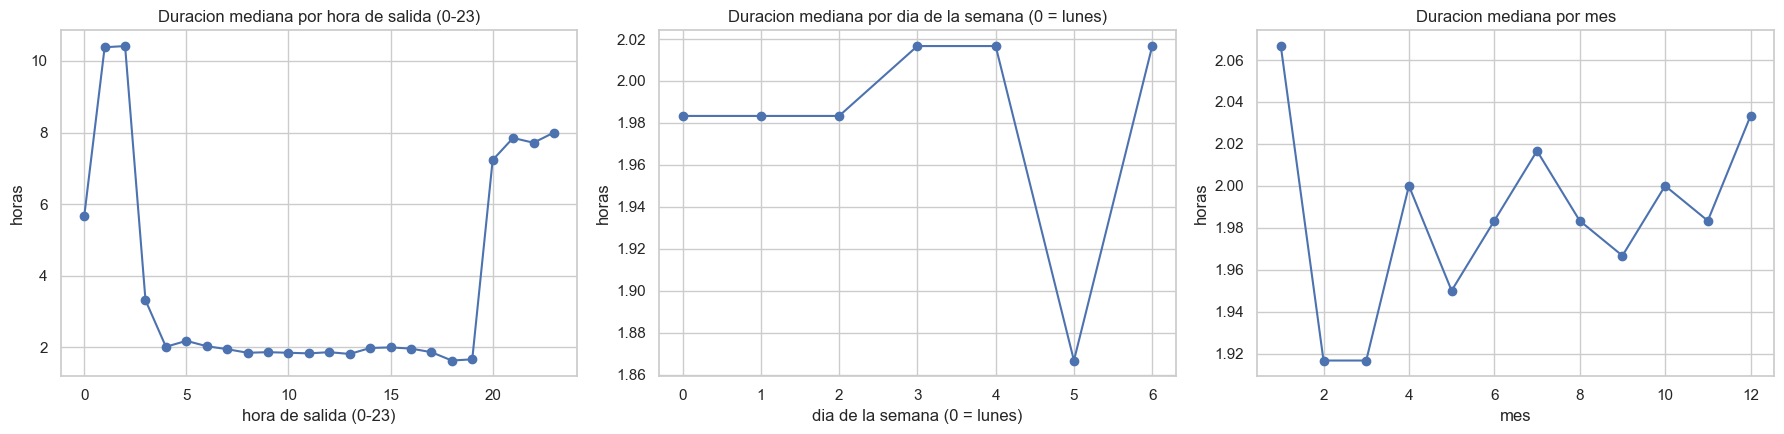

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (col, etiqueta) in zip(axes, [("hora_salida_decimal", "hora de salida (0-23)"),
                                       ("dia_semana", "dia de la semana (0 = lunes)"),
                                       ("mes", "mes")]):
    clave = df.loc[ok, col].astype(int) if col == "hora_salida_decimal" else df.loc[ok, col]
    med = df.loc[ok, "duracion_viaje_horas"].groupby(clave).median()
    ax.plot(med.index, med.values, marker="o")
    ax.set_title(f"Duracion mediana por {etiqueta}")
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("horas")
plt.tight_layout()
plt.show()


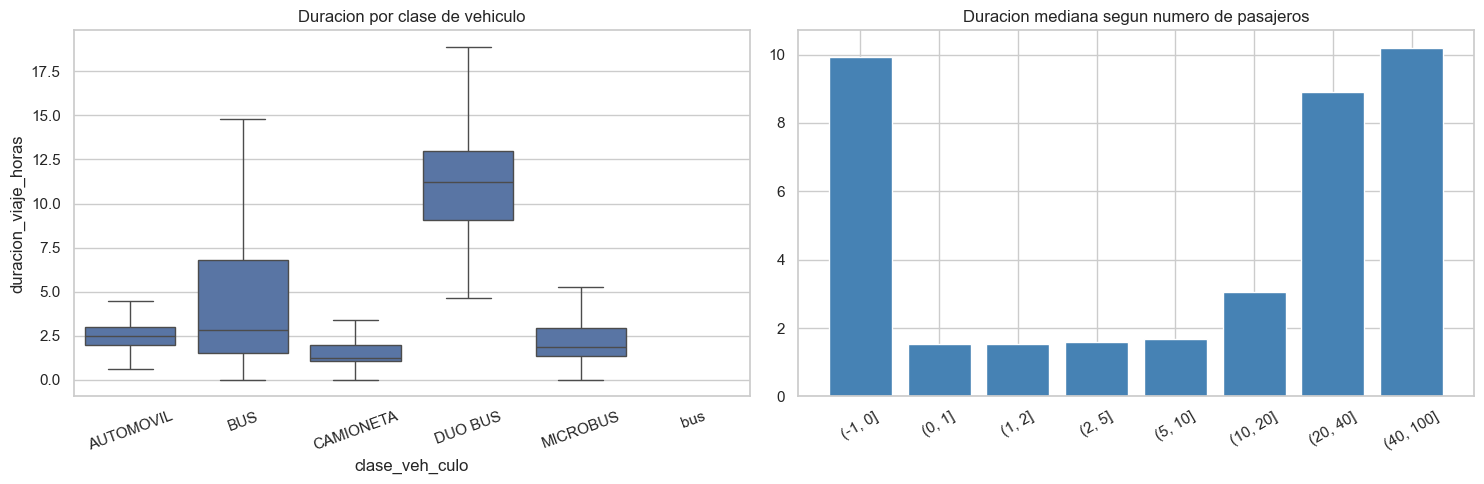

In [30]:
muestra_plot = df[ok].sample(300_000, random_state=SEED)      # solo para acelerar el grafico
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=muestra_plot, x="clase_veh_culo", y="duracion_viaje_horas", showfliers=False, ax=axes[0])
axes[0].set_title("Duracion por clase de vehiculo")
axes[0].tick_params(axis="x", rotation=20)
bins_pas = pd.cut(df.loc[ok, "pasajeros"], [-1, 0, 1, 2, 5, 10, 20, 40, 100])
med_pas = df.loc[ok, "duracion_viaje_horas"].groupby(bins_pas, observed=True).median()
axes[1].bar(range(len(med_pas)), med_pas.values, color="steelblue")
axes[1].set_xticks(range(len(med_pas)))
axes[1].set_xticklabels([str(i) for i in med_pas.index], rotation=30)
axes[1].set_title("Duracion mediana segun numero de pasajeros")
plt.tight_layout()
plt.show()


**Lectura** (medianas de la duración sobre filas con duración válida):

- **Clase de vehículo:** DUO BUS 11.3 h, BUS 2.8 h (rango intercuartílico 1.5-6.8 h), AUTOMOVIL 2.5 h, MICROBUS 1.8 h, CAMIONETA 1.2 h. La clase importa, y dentro de los BUS hay mucha dispersión (conviven rutas cortas y largas).
- **Terminal:** Norte 1.8 h vs. Sur 2.6 h. **Subregión:** Centro 4.5 h, Sur 3.4 h, Norte 2.8 h, Occidente y Oriente 1.4 h.
- **Empresa y ruta: la variable con más señal.** Entre las 76 empresas con al menos 1.000 viajes, la duración mediana va de **0.95 h a 19.4 h**; entre las 253 rutas con al menos 1.000 viajes, de **0.93 h a 21.1 h**. Ese rango tan amplio es la razón para **conservar todas las categorías** de `empresa` y `ruta_origen` sin agruparlas en "otros": agruparlas destruiría justamente la información más útil del problema.
- **Hora de salida (efecto no lineal):** la duración mediana es de ~1.6-2.2 h para salidas entre las 4:00 y las 19:00, pero sube a **5.7-10.4 h para salidas entre las 20:00 y las 2:00** (los viajes nocturnos son de larga distancia). Un efecto así no lo capta una correlación lineal, y es un argumento para tratar la hora con modelos capaces de captar no linealidades (árboles) o con una codificación adecuada.
- **Día de la semana y mes:** las medianas casi no cambian (1.87-2.02 h por día; 1.92-2.07 h por mes): no se observa estacionalidad ni efecto de fin de semana en la mediana. Aun así se conservan como predictoras, porque pueden interactuar con la ruta o la empresa, y su costo es bajo.
- **Pasajeros:** la duración mediana crece con el número de pasajeros (≈1.5-1.7 h con 1 a 10 pasajeros; ≈3.1 h con 11 a 20; ≈8.9 h con 21 a 40), pero, como se vio en el Paso 8, esa relación refleja la ruta y el tamaño del vehículo.


# Resumen — hallazgos y decisiones que respalda esta exploración

Este notebook no modifica ni descarta ninguna columna: recoge la evidencia. Con ella, en el notebook de preparación de datos se decide:

1. **Eliminar `estado` y `ruta_destino`**: constantes (Paso 4).
2. **Normalizar mayúsculas y espacios** en `nombre_sucursal`, `subregi_n` y `clase_veh_culo` (Paso 4).
3. **Hora de salida real** = `fecha_hora_salida_origen` con respaldo en `fecha_salida`; llegada = `hora_de_llegada`; de la salida real se derivan `hora_salida_decimal`, `dia_semana` y `mes` (Paso 6).
4. **Valores faltantes:** `fecha_hora_salida_origen` (33.43%, MAR por período) se complementa con `fecha_salida`, sin imputación estadística; `empresa` y `clase_veh_culo` faltantes pasan a la categoría `DESCONOCIDA`; solo se eliminan las 5 filas sin ninguna hora de salida (Pasos 2, 5 y 6).
5. **Fechas de salida imposibles** (34 filas): se conservan, tomando mes y día de la semana de la fecha de llegada (Paso 6).
6. **Duraciones inválidas: no se eliminan, se reemplazan.** Criterio por ruta (negativa, o más de 12 h sobre la mediana de su ruta) y reemplazo por la mediana de su ruta calculada solo con el conjunto de entrenamiento. Un corte fijo de 24 h destruiría unos 4.300 viajes largos legítimos (Paso 7).
7. **Categorías de `ruta_origen` (412) y `empresa` (169): se conservan sin agrupar**, porque la duración mediana varía entre 0.93 y 21.1 h según la ruta y entre 0.95 y 19.4 h según la empresa (Paso 9).
8. **Predictoras:** `nombre_sucursal`, `empresa`, `ruta_origen`, `subregi_n`, `clase_veh_culo`, `pasajeros`, `hora_salida_decimal`, `dia_semana` y `mes`. No hay redundancia fuerte entre las numéricas (Paso 8).

**Puntos a vigilar al modelar:** la relación hora-duración es no lineal (Paso 9); `pasajeros` se comporta como un proxy de la ruta (Paso 8); las variables cíclicas (`dia_semana`, `mes`, hora) y las de escala distinta requieren codificación o escalado adecuados según el algoritmo; hay 3.790 filas duplicadas (0.14%) que pueden caer a ambos lados de la separación entrenamiento/prueba.
